In [9]:
from keras.layers import Dense, Conv2D, Flatten, AveragePooling2D
from keras import Sequential
from keras.datasets import mnist
import numpy as np

In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

We pad the 28 X 28 image to 32 X 32 since LeNET-5 takes 32 X 32 img

In [10]:
x_train = np.pad(
    x_train,
    ((0, 0), (2, 2), (2, 2)),
    mode='constant'
)

x_test = np.pad(
    x_test,
    ((0, 0), (2, 2), (2, 2)),
    mode='constant'
)

# Add channel dimension: (N, 32, 32) → (N, 32, 32, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print(x_train.shape)
print(x_test.shape)

(60000, 32, 32, 1)
(10000, 32, 32, 1)


<h1>LeNET 5 Architecture</h1>

In [11]:
model = Sequential()

# Layer 1
model.add(Conv2D(6, kernel_size = (5, 5), padding = 'valid', activation = 'tanh', input_shape = (32, 32, 1)))
model.add(AveragePooling2D(pool_size=(2,2), strides = 2, padding='valid'))

# Layer 2
model.add(Conv2D(6, kernel_size = (5, 5), padding = 'valid', activation = 'tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides = 2, padding='valid'))


model.add(Flatten())

# Layer 3
model.add(Dense(120, activation = 'tanh'))

# Layer 4
model.add(Dense(84, activation = 'tanh'))

# Layer 5
model.add(Dense(10, activation = 'softmax'))

d:\Downloads\Deep-Learning\Deep-Learning-main\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs = 30, validation_data=(x_test, y_test))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9498 - loss: 0.1720 - val_accuracy: 0.9715 - val_loss: 0.0905
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9790 - loss: 0.0686 - val_accuracy: 0.9810 - val_loss: 0.0588
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9834 - loss: 0.0529 - val_accuracy: 0.9838 - val_loss: 0.0511
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9861 - loss: 0.0439 - val_accuracy: 0.9861 - val_loss: 0.0434
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9888 - loss: 0.0353 - val_accuracy: 0.9850 - val_loss: 0.0456
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9895 - loss: 0.0317 - val_accuracy: 0.9841 - val_loss: 0.0484
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9903 - loss: 0.0291 - val_accuracy: 0.9865 - val_loss: 0.0451
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9920 - loss: 0.0246 - 

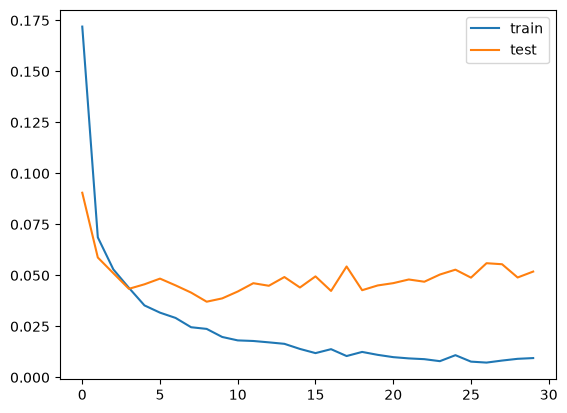

In [13]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'test')
plt.legend()
plt.show()